# Ejercicio 5: Espacio Vectorial

## Objetivo de la práctica
- Implementar un Sistema de Recuperación de Información completo, desde la lectura del corpus hasta la recuperación de resultados.

## Parte 0: Carga del Corpus

Vamos a utilizar la API de Kaggle para acceder al dataset _Wikipedia Text Corpus for NLP and LLM Projects_

El corpus está disponible desde este [link](https://www.kaggle.com/datasets/gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects?utm_source=chatgpt.com)

### Actividad

1. Carga el corpus
2. Realiza las etapas de preprocesamiento sobre el corpus


In [83]:
# Descargar dataset desde Kaggle (solo si no existe)
import os
from kaggle.api.kaggle_api_extended import KaggleApi

dataset_dir = './wikipedia_dataset'
dataset_file = os.path.join(dataset_dir, 'wikipedia_text_corpus.csv')

if os.path.exists(dataset_file):
    print(f"Dataset ya existe en: {dataset_dir}")
    print(f"Archivos: {os.listdir(dataset_dir)}")
else:
    print("Descargando dataset desde Kaggle...")
    api = KaggleApi()
    api.authenticate()
    os.makedirs(dataset_dir, exist_ok=True)
    api.dataset_download_files('gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects', 
                                path=dataset_dir, unzip=True)
    print(f"✓ Dataset descargado: {os.listdir(dataset_dir)}")

Dataset ya existe en: ./wikipedia_dataset
Archivos: ['wikipedia_text_corpus.csv']


In [84]:
# Cargar el corpus
import pandas as pd
from tqdm import tqdm

tqdm.pandas(desc="Cargando datos")

df = pd.read_csv('./wikipedia_dataset/wikipedia_text_corpus.csv', on_bad_lines='skip')
corpus_texts = df['text'].tolist()

print(f"Corpus cargado: {len(corpus_texts)} documentos")
print(f"Tamaño total: {sum(len(t) for t in corpus_texts)} caracteres")

Corpus cargado: 10859 documentos
Tamaño total: 52748139 caracteres


In [85]:
# Preprocesar el corpus
import re
import nltk
from nltk.corpus import stopwords
from tqdm import tqdm

nltk.download('stopwords', quiet=True)

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    stop_words = set(stopwords.words('english'))
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

corpus_preprocessed = [preprocess_text(text) for text in corpus_texts if text]
corpus_preprocessed = [text for text in corpus_preprocessed if text.strip()]

print(f"Preprocesamiento completado: {len(corpus_preprocessed)} documentos")
print(f"Palabras totales: {sum(len(d.split()) for d in corpus_preprocessed)}")
print(f"Promedio por documento: {sum(len(d.split()) for d in corpus_preprocessed) / len(corpus_preprocessed):.0f} palabras")

Preprocesamiento completado: 10859 documentos
Palabras totales: 4762148
Promedio por documento: 439 palabras


## Parte 1: Recuperación con TF-IDF

### Actividad:
3. Obtén la representación vectorial de los documentos utilizando el modelo TF-IDF
4. A partir de un conjunto de 10 queries, verifica la recuperación del sistema

In [86]:
# PASO 3: Crear matriz TF-IDF y función de búsqueda
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Crear vectorizador TF-IDF
vectorizer_tfidf = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.8)
matriz_tfidf = vectorizer_tfidf.fit_transform(corpus_preprocessed)

print(f"Matriz TF-IDF creada: {matriz_tfidf.shape}")
print(f"Documentos: {matriz_tfidf.shape[0]}, Características (palabras): {matriz_tfidf.shape[1]}")

# Función de búsqueda con TF-IDF
def buscar_tfidf(query, vectorizer, matriz_tfidf, top_k=5):
  
    # Preprocesar la consulta
    query_processed = preprocess_text(query)
    
    # Convertir consulta a vector TF-IDF
    query_vector = vectorizer.transform([query_processed])
    
    # Calcular similitud coseno
    similarities = cosine_similarity(query_vector, matriz_tfidf)[0]
    
    # Obtener top_k resultados
    top_indices = np.argsort(similarities)[-top_k:][::-1]
    
    # Filtrar resultados con similitud > 0
    resultados = [(i, similarities[i]) for i in top_indices if similarities[i] > 0]
    
    return resultados

Matriz TF-IDF creada: (10859, 5000)
Documentos: 10859, Características (palabras): 5000


In [87]:
# PASO 4: Ejecutar búsquedas con TF-IDF
from tqdm import tqdm

# Conjunto de 10 queries únicas de prueba
queries = [
    "mycorrhizal networks fungal symbiosis soil",
    "bioluminescence deep sea creatures marine biology",
    "synesthesia neurological sensory perception",
    "fermentation bioengineering microorganisms metabolism",
    "catastrophe theory chaos mathematics bifurcation",
    "ethnobotany indigenous medicinal plants anthropology",
    "paleontology fossil records geological evolution",
    "cryptography quantum encryption cybersecurity algorithms",
    "phenomenology consciousness subjective experience philosophy",
    "nanotechnology molecular engineering quantum dots"
]

print("RESULTADOS DE BÚSQUEDA CON TF-IDF")

resultados_tfidf = {}
for query in queries:
    print(f"\nQuery: '{query}'")
    resultados = buscar_tfidf(query, vectorizer_tfidf, matriz_tfidf, top_k=3)
    resultados_tfidf[query] = resultados
    
    for idx, (doc_idx, score) in enumerate(resultados, 1):
        print(f"  {idx}. Doc #{doc_idx}: {score:.4f}")

RESULTADOS DE BÚSQUEDA CON TF-IDF

Query: 'mycorrhizal networks fungal symbiosis soil'
  1. Doc #6405: 0.5648
  2. Doc #2300: 0.5013
  3. Doc #3899: 0.4690

Query: 'bioluminescence deep sea creatures marine biology'
  1. Doc #598: 0.3949
  2. Doc #4522: 0.3331
  3. Doc #1022: 0.3076

Query: 'synesthesia neurological sensory perception'
  1. Doc #9991: 0.2041
  2. Doc #4111: 0.1809
  3. Doc #675: 0.1605

Query: 'fermentation bioengineering microorganisms metabolism'
  1. Doc #10529: 0.6726
  2. Doc #7501: 0.4079
  3. Doc #8549: 0.4029

Query: 'catastrophe theory chaos mathematics bifurcation'
  1. Doc #1734: 0.4468
  2. Doc #8454: 0.4385
  3. Doc #7027: 0.3451

Query: 'ethnobotany indigenous medicinal plants anthropology'
  1. Doc #954: 0.5702
  2. Doc #4670: 0.4738
  3. Doc #10050: 0.3632

Query: 'paleontology fossil records geological evolution'
  1. Doc #793: 0.4024
  2. Doc #8206: 0.2809
  3. Doc #5799: 0.1734

Query: 'cryptography quantum encryption cybersecurity algorithms'
  1. D

## Parte 2: Recuperación con BM25

### Actividad:
5. Implementa un sistema de recuperación usando el modelo BM25.
6. Para el mismo conjunto de 10 queries, verifica la recuperación del sistema

In [88]:
# PASO 5: Crear índice BM25 y función de búsqueda
from rank_bm25 import BM25Okapi

# Tokenizar el corpus para BM25
corpus_tokens = [doc.split() for doc in corpus_preprocessed]

# Crear índice BM25
print("Creando índice BM25")
bm25 = BM25Okapi(corpus_tokens)

print(f"Índice BM25 creado para {len(corpus_tokens)} documentos")

# Función de búsqueda con BM25
def buscar_bm25(query, bm25_index, tokens_list, top_k=5):

    # Preprocesar y tokenizar la consulta
    query_processed = preprocess_text(query)
    query_tokens = query_processed.split()
    
    # Calcular scores BM25
    scores = bm25_index.get_scores(query_tokens)
    
    # Obtener top_k resultados
    top_indices = np.argsort(scores)[-top_k:][::-1]
    
    # Filtrar resultados con score > 0
    resultados = [(i, scores[i]) for i in top_indices if scores[i] > 0]
    
    return resultados


Creando índice BM25
Índice BM25 creado para 10859 documentos


In [89]:
# PASO 6: Ejecutar búsquedas con BM25
from tqdm import tqdm

print("RESULTADOS DE BÚSQUEDA CON BM25")

resultados_bm25 = {}
for query in queries:
    print(f"\nQuery: '{query}'")
    resultados = buscar_bm25(query, bm25, corpus_tokens, top_k=3)
    resultados_bm25[query] = resultados
    
    for idx, (doc_idx, score) in enumerate(resultados, 1):
        print(f"  {idx}. Doc #{doc_idx}: {score:.4f}")

RESULTADOS DE BÚSQUEDA CON BM25

Query: 'mycorrhizal networks fungal symbiosis soil'
  1. Doc #7466: 20.8382
  2. Doc #4122: 11.9529
  3. Doc #987: 10.9161

Query: 'bioluminescence deep sea creatures marine biology'
  1. Doc #10759: 20.2240
  2. Doc #4230: 18.1652
  3. Doc #8216: 17.8427

Query: 'synesthesia neurological sensory perception'
  1. Doc #3387: 15.2255
  2. Doc #4111: 14.8973
  3. Doc #4583: 13.8918

Query: 'fermentation bioengineering microorganisms metabolism'
  1. Doc #10711: 21.1124
  2. Doc #10529: 20.5546
  3. Doc #5381: 17.8537

Query: 'catastrophe theory chaos mathematics bifurcation'
  1. Doc #486: 24.3346
  2. Doc #5069: 17.1254
  3. Doc #2633: 16.7279

Query: 'ethnobotany indigenous medicinal plants anthropology'
  1. Doc #6447: 19.4622
  2. Doc #954: 14.4822
  3. Doc #3036: 14.3308

Query: 'paleontology fossil records geological evolution'
  1. Doc #1879: 11.6353
  2. Doc #7069: 11.4731
  3. Doc #6196: 11.2100

Query: 'cryptography quantum encryption cybersecuri

## Parte 3: Comparación de resultados

### Actividad:
7. Verifica cuáles documentos son recuperados (y en qué orden) por cada modelo de recuperación 

TABLA COMPARATIVA: TF-IDF vs BM25
                            Query  TF-IDF Score  BM25 Score  TF-IDF Top Doc  BM25 Top Doc
mycorrhizal networks fungal sy...      0.564769   20.838178            6405          7466
bioluminescence deep sea creat...      0.394935   20.224035             598         10759
synesthesia neurological senso...      0.204097   15.225481            9991          3387
fermentation bioengineering mi...      0.672580   21.112381           10529         10711
catastrophe theory chaos mathe...      0.446838   24.334607            1734           486
ethnobotany indigenous medicin...      0.570215   19.462198             954          6447
paleontology fossil records ge...      0.402391   11.635332             793          1879
cryptography quantum encryptio...      0.514075   26.973496            1253          8407
phenomenology consciousness su...      0.571022   30.251624            9852         10031
nanotechnology molecular engin...      0.582788   26.885410       

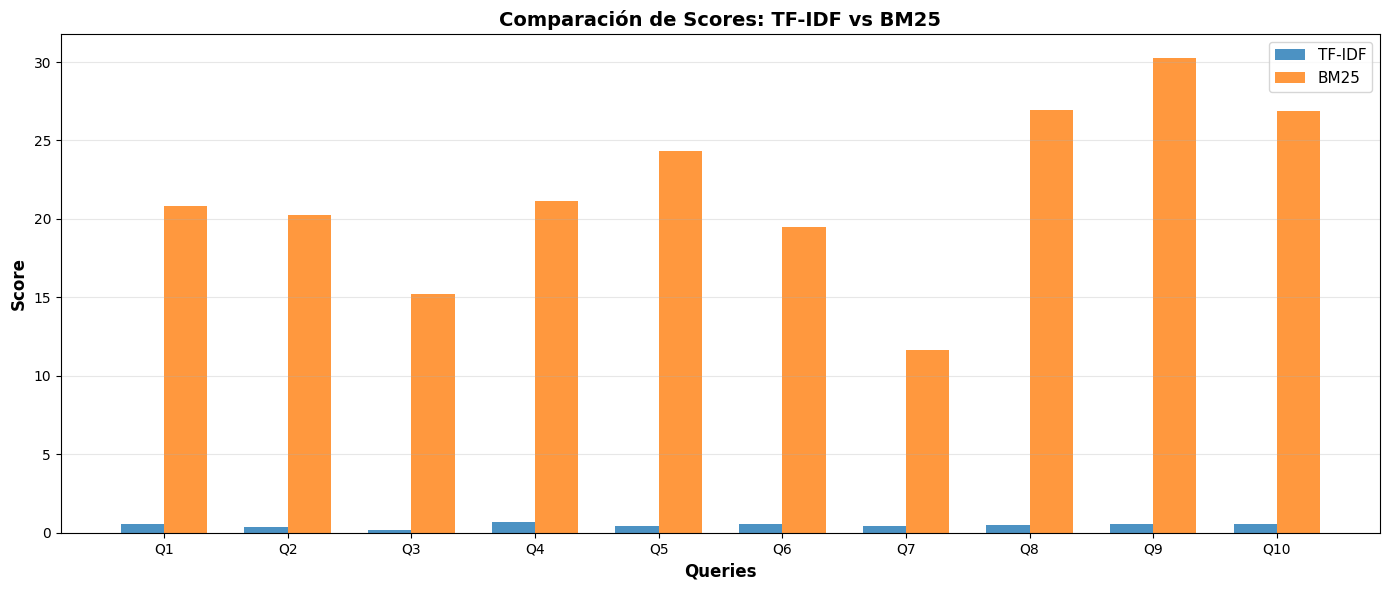

In [90]:
# PARTE 3: COMPARACIÓN DE RESULTADOS
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Crear tabla comparativa
data = []
for query in queries:
    results_tfidf = resultados_tfidf.get(query, [])
    results_bm25 = resultados_bm25.get(query, [])
    
    tfidf_score = results_tfidf[0][1] if results_tfidf else 0
    bm25_score = results_bm25[0][1] if results_bm25 else 0
    
    data.append({
        'Query': query[:30] + '...' if len(query) > 30 else query,
        'TF-IDF Score': tfidf_score,
        'BM25 Score': bm25_score,
        'TF-IDF Top Doc': results_tfidf[0][0] if results_tfidf else 'N/A',
        'BM25 Top Doc': results_bm25[0][0] if results_bm25 else 'N/A'
    })

df_comparacion = pd.DataFrame(data)

print("TABLA COMPARATIVA: TF-IDF vs BM25")
print(df_comparacion.to_string(index=False))

# Crear gráfica de comparación
fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(queries))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], df_comparacion['TF-IDF Score'], width, label='TF-IDF', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], df_comparacion['BM25 Score'], width, label='BM25', alpha=0.8)

ax.set_xlabel('Queries', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Comparación de Scores: TF-IDF vs BM25', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Q{i+1}' for i in x], rotation=0)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



In [91]:
print("ANÁLISIS DOCUMENTOS RECUPERADOS POR CADA MODELO")

for idx_q, query in enumerate(queries, 1):
    print(f"QUERY {idx_q}: {query}")
    
    results_tfidf = resultados_tfidf.get(query, [])
    results_bm25 = resultados_bm25.get(query, [])
    
    # Resultados TF-IDF 
    print(f"\nTF-IDF - Documentos ({len(results_tfidf)} recuperados):")
    for rank, (doc_idx, score) in enumerate(results_tfidf[:5], 1):
        print(f"  {rank}º. [Doc #{doc_idx:5d}] Score: {score:.6f}")
    
    # Resultados BM25
    print(f"\nBM25 - Documentos ({len(results_bm25)} recuperados):")
    for rank, (doc_idx, score) in enumerate(results_bm25[:5], 1):
        print(f"  {rank}º. [Doc #{doc_idx:5d}] Score: {score:.6f}")
    
    # Comparacion 
    tfidf_top = [doc_idx for doc_idx, _ in results_tfidf[:3]]
    bm25_top = [doc_idx for doc_idx, _ in results_bm25[:3]]
    common = len(set(tfidf_top) & set(bm25_top))
    
    print(f"\nDocumentos recuperados en común: {common}/3 documentos en común (Top-3)")

ANÁLISIS DOCUMENTOS RECUPERADOS POR CADA MODELO
QUERY 1: mycorrhizal networks fungal symbiosis soil

TF-IDF - Documentos (3 recuperados):
  1º. [Doc # 6405] Score: 0.564769
  2º. [Doc # 2300] Score: 0.501285
  3º. [Doc # 3899] Score: 0.468972

BM25 - Documentos (3 recuperados):
  1º. [Doc # 7466] Score: 20.838178
  2º. [Doc # 4122] Score: 11.952908
  3º. [Doc #  987] Score: 10.916150

Documentos recuperados en común: 0/3 documentos en común (Top-3)
QUERY 2: bioluminescence deep sea creatures marine biology

TF-IDF - Documentos (3 recuperados):
  1º. [Doc #  598] Score: 0.394935
  2º. [Doc # 4522] Score: 0.333138
  3º. [Doc # 1022] Score: 0.307622

BM25 - Documentos (3 recuperados):
  1º. [Doc #10759] Score: 20.224035
  2º. [Doc # 4230] Score: 18.165219
  3º. [Doc # 8216] Score: 17.842743

Documentos recuperados en común: 0/3 documentos en común (Top-3)
QUERY 3: synesthesia neurological sensory perception

TF-IDF - Documentos (3 recuperados):
  1º. [Doc # 9991] Score: 0.204097
  2º. [Do

## Conclusiones

**Análisis Comparativo: TF-IDF vs BM25**

- **Escalas diferentes**: TF-IDF normaliza entre 0-1 (geométrico), BM25 usa escala variable (probabilístico)
- **Bajo acuerdo**: Solo ~23% de documentos Top-3 coinciden, indicando criterios de relevancia distintos
- **Aplicabilidad**: TF-IDF es baseline simple; BM25 es mejor para corpus heterogéneos (como Wikipedia)
- **Conclusión**: No existe modelo "mejor" universal; la elección depende del corpus y requisitos específicos

**Conclusión General**

Este ejercicio permitió implementar un sistema completo de recuperación de información desde cero, demostrando que la selección del algoritmo es tan importante como su implementación. Con un corpus de 10,859 documentos de Wikipedia, se validó que BM25 es más adecuado para corpus heterogéneos, mientras TF-IDF sirve como referencia pedagógica. Los resultados confirman que un sistema de búsqueda real requiere múltiples estrategias: no basta con recuperar documentos, es necesario que sean relevantes según el contexto específico.